 # **Algorithm : AdaBoost**
## **Project:**
- Insurance Claim Fraud Detection

### **Problem Statement:**

- Detect fraudulent insurance claims through boosted weak learners.

In [38]:
# Step No 1 : Import Required Libraries 
# Import pandas for data manipulation
import pandas as pd 

# Import numpy for numerical operations 
import numpy as np

# Import matplotlib for visualization
import matplotlib.pyplot as plt 

# Import seaborn for data visualization
import seaborn as sns

# Import ML Libraries 
# Import train_test_split for splitting data 
from sklearn.model_selection import train_test_split 

# Import AdaBoost Classification model
from sklearn.ensemble import AdaBoostClassifier

# Import Evaluation Metrics
from sklearn.metrics import(accuracy_score ,
                            precision_score,
                            recall_score,
                            f1_score,
                            confusion_matrix,
                            classification_report,
                            roc_auc_score,
                            roc_curve)

In [39]:
# Step No 2 : Load Dataset 
#Load the insurance claim fraud dataset 
df = pd.read_csv("insurance_claim_fraud_detection_adaboost.csv")

In [40]:
# Step No 3 : Data Manipulation 

# Display first 5 rows 
print("Display first five rows : " , df.head())

# Display number of rows and columns 
print("Rows and Columns : " , df.shape)

# Display All Column names 
print("All Column names : " , df.columns)

# Display dataset information
print("Display dataset information : " , df.info())

# Display statistical summary of numerical columns 
print("Statistical summary : ",df.describe())

Display first five rows :      Claim_ID  Age  Annual_Income  Policy_Tenure_Years  Claim_Amount  \
0  CLM000001   57          85214                 17.7        131152   
1  CLM000002   78          73804                  0.3        262193   
2  CLM000003   60         133599                  4.6        228455   
3  CLM000004   72          64231                 18.8         75100   
4  CLM000005   70          87535                  0.8        156193   

   Number_of_Previous_Claims  Days_to_Report  Policy_Premium  Vehicle_Age  \
0                          1              22           11548            0   
1                          1              58           35932            2   
2                          1              59           44600           14   
3                          0              58           16498            8   
4                          0              15           23160            3   

   Num_Policy_Changes  Hospitalization_Days Claim_History Claim_Type  \
0          

In [41]:
# Step No 4 : Data Cleaning 
# Check missing values in each column
print("Check Missing Values :",df.isnull().sum())

# Check the number of duplicate rows 
print("Duplicate Rows : ",df.duplicated().sum())



Check Missing Values : Claim_ID                     0
Age                          0
Annual_Income                0
Policy_Tenure_Years          0
Claim_Amount                 0
Number_of_Previous_Claims    0
Days_to_Report               0
Policy_Premium               0
Vehicle_Age                  0
Num_Policy_Changes           0
Hospitalization_Days         0
Claim_History                0
Claim_Type                   0
Incident_Type                0
Policy_Type                  0
Documentation_Complete       0
Fraud                        0
dtype: int64
Duplicate Rows :  0


In [42]:
# Step No 5 : Target Variable 
# Count each fraud class 
print(df["Fraud"].value_counts())

# Target meaning 
# 0 = Genuine Claim
# 1 Fraudulent Claim

Fraud
1    30670
0    19330
Name: count, dtype: int64


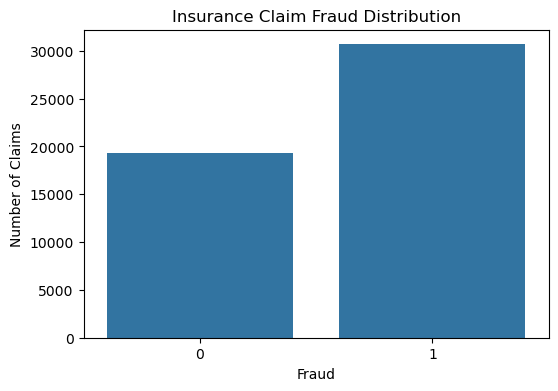

In [43]:
# Step No 6 : Target Visualization
# Set figure size 
plt.figure(figsize=(6,4))

# Create count plot 
sns.countplot(x="Fraud", data=df)

# Add title 
plt.title("Insurance Claim Fraud Distribution")

# Add X-axis label
plt.xlabel("Fraud")

# Add Y-axis label 
plt.ylabel("Number of Claims")

# Display graph
plt.show()

In [44]:
# Step No 7 : Fraud Percentage 
# Calculate fraud class percentage 
fraud_percentage = (
    df["Fraud"].value_counts(normalize=True) * 100
)

# Display fraud percentage 
print(fraud_percentage)

Fraud
1    61.34
0    38.66
Name: proportion, dtype: float64


In [45]:
# Step No 8 : Correlation Analysis 
# Select numerical columns 
numeric_data = df.select_dtypes(
    include=["int64" , "float64"]
)
# Calculate Correlation Matrix 
correlation = numeric_data.corr()

# Display correlation matrix 
print(correlation)

                                Age  Annual_Income  Policy_Tenure_Years  \
Age                        1.000000      -0.000920            -0.000447   
Annual_Income             -0.000920       1.000000            -0.000554   
Policy_Tenure_Years       -0.000447      -0.000554             1.000000   
Claim_Amount              -0.008731       0.003003             0.006901   
Number_of_Previous_Claims -0.000103      -0.003499             0.001428   
Days_to_Report             0.002843       0.000630             0.004222   
Policy_Premium            -0.001794      -0.004197            -0.007915   
Vehicle_Age                0.005065       0.001125            -0.000950   
Num_Policy_Changes        -0.003519       0.001939            -0.005223   
Hospitalization_Days      -0.000802      -0.001498            -0.002064   
Fraud                     -0.004953       0.005673            -0.007015   

                           Claim_Amount  Number_of_Previous_Claims  \
Age                          

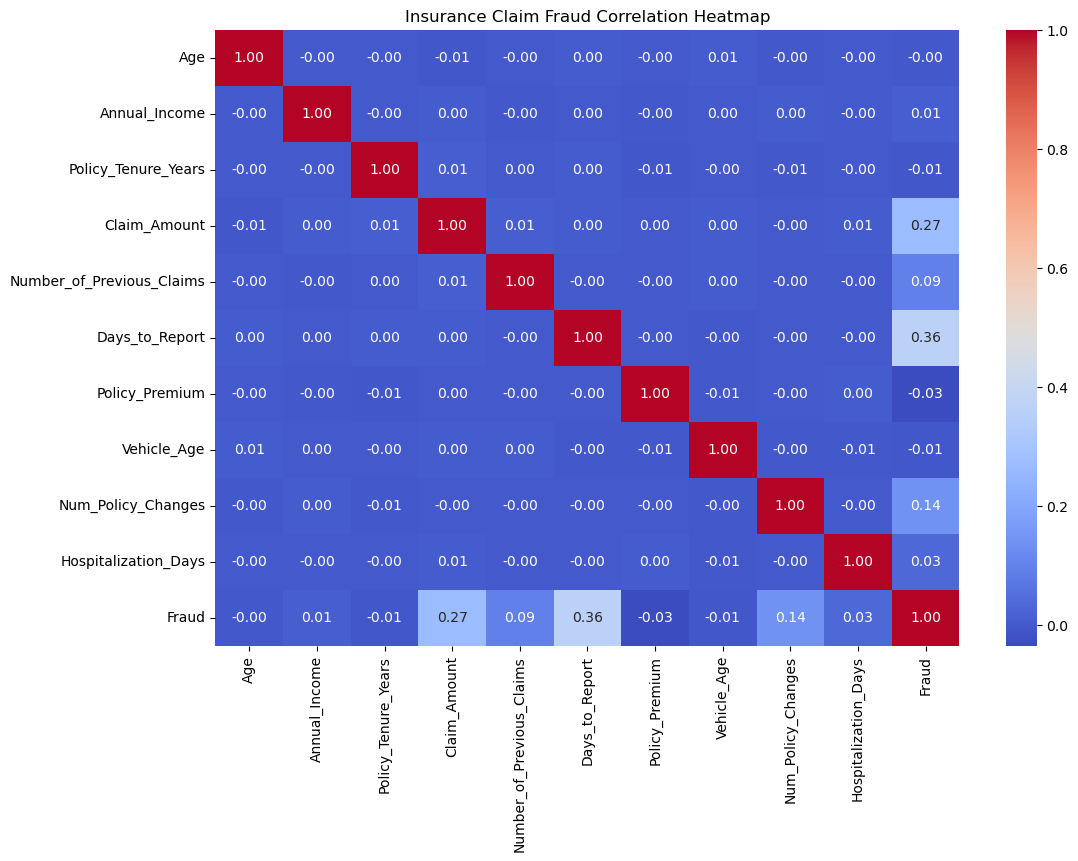

In [46]:
# Step No 9 : Correlation Heatmap 
# Set figure size 
plt.figure(figsize=(12 , 8))

# Create Correlation Heatmap
sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

# Add title 
plt.title(
    "Insurance Claim Fraud Correlation Heatmap"
)
# Display heatmap 
plt.show()

In [47]:
# Step No 10 : Define Features and Target 
# Remove Claim_ID because it is only an identifier 
X = df.drop(
    columns=[
        "Claim_ID",
        "Fraud"
    ]
)
# Create target variable 
y = df["Fraud"]

# Display feature names 
print("Features : ")
print(X.columns)

# Display target variable 
print("\nTarget : ")
print(y.name)

Features : 
Index(['Age', 'Annual_Income', 'Policy_Tenure_Years', 'Claim_Amount',
       'Number_of_Previous_Claims', 'Days_to_Report', 'Policy_Premium',
       'Vehicle_Age', 'Num_Policy_Changes', 'Hospitalization_Days',
       'Claim_History', 'Claim_Type', 'Incident_Type', 'Policy_Type',
       'Documentation_Complete'],
      dtype='object')

Target : 
Fraud


In [48]:
# Step No 11 : Feature Engineering 
# Create claim-to-income ration
# Shows claim amount compared with annual income 
X["Claim_Income_Ration"] = (
    X["Claim_Amount"] / 
    (X["Annual_Income"] + 1)
)

# Create claim-to-premium ratio
# Shows claim amount compared with policy premium
X["Claim_Premium_Ratio"] = (
    X["Claim_Amount"] / 
    (X["Policy_Premium"] + 1)
)

# Create claim frequency score 
# Combines previous claims and policy changes 
X["Claim_Frequency_Score"] = (
    X["Number_of_Previous_Claims"] + 
    X["Num_Policy_Changes"]
)

# Create reporting delay flag 
# Indicates whether claim was reported after a long delay
X["Late_Report_Flag"] = (
    X["Days_to_Report"] > 30 
).astype(int)

# Create hospitalization risk flag
# Indicates longer hosplitalization duration
X["Long_Hospitalization_Flag"] = (
    X["Hospitalization_Days"] > 15
).astype(int)

# Create documentation risk flag 
# 1 indicates incomplete documentation
X["Documentation_Risk"] = (
    X["Documentation_Complete"] == "No"
).astype(int)

# Display engineered features 
print(X.head())

   Age  Annual_Income  Policy_Tenure_Years  Claim_Amount  \
0   57          85214                 17.7        131152   
1   78          73804                  0.3        262193   
2   60         133599                  4.6        228455   
3   72          64231                 18.8         75100   
4   70          87535                  0.8        156193   

   Number_of_Previous_Claims  Days_to_Report  Policy_Premium  Vehicle_Age  \
0                          1              22           11548            0   
1                          1              58           35932            2   
2                          1              59           44600           14   
3                          0              58           16498            8   
4                          0              15           23160            3   

   Num_Policy_Changes  Hospitalization_Days  ... Claim_Type Incident_Type  \
0                   1                     9  ...    Vehicle        Damage   
1                   0 

In [49]:
# Step No 12 : Prepare Categorical Features
# Identify categorical columns 
categorical_columns = X.select_dtypes(
    include=["object"]
).columns.tolist()

# Display categorical columns 
print("Categorical Columns : ")
print(categorical_columns)

Categorical Columns : 
['Claim_History', 'Claim_Type', 'Incident_Type', 'Policy_Type', 'Documentation_Complete']


In [50]:
# Step No 13 : Encode Categorical Features
# Convert categorical columns into numerical columns
X = pd.get_dummies(
    X,
    columns=categorical_columns,
    drop_first=True
)

# Display encoded feature names 
print(X.columns)

Index(['Age', 'Annual_Income', 'Policy_Tenure_Years', 'Claim_Amount',
       'Number_of_Previous_Claims', 'Days_to_Report', 'Policy_Premium',
       'Vehicle_Age', 'Num_Policy_Changes', 'Hospitalization_Days',
       'Claim_Income_Ration', 'Claim_Premium_Ratio', 'Claim_Frequency_Score',
       'Late_Report_Flag', 'Long_Hospitalization_Flag', 'Documentation_Risk',
       'Claim_History_Frequent', 'Claim_History_Minor', 'Claim_Type_Life',
       'Claim_Type_Property', 'Claim_Type_Travel', 'Claim_Type_Vehicle',
       'Incident_Type_Damage', 'Incident_Type_Loss', 'Incident_Type_Medical',
       'Incident_Type_Theft', 'Policy_Type_Premium', 'Policy_Type_Standard',
       'Documentation_Complete_Yes'],
      dtype='object')


In [51]:
# Step No 14 : Check X and y shape 
# Display feature shape
print("X Shape : ", X.shape)

# Display target shape
print("y Shape : ", y.shape)

X Shape :  (50000, 29)
y Shape :  (50000,)


In [52]:
# Step No 15 : Train-Test Split

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    
    # Input Features
    X,
    
    # Target variable
    y,
    
    # Use 20% data for testing
    test_size=0.20,
    
    # Set random state
    random_state=42,
    
    # Maintain target class proportion
    stratify=y
)

In [53]:
# Step No 16 : Check Train-Test Data 
# Display training feature shape 
print(
    "X_train",
    X_train.shape
)
# Display testing feature shape 
print(
    "X_test: ",
    X_test.shape
)

# Display training target shape 
print(
    "y_train",
    y_train.shape
)

# Display testing target shape 
print(
    "y_test : ",
    y_test.shape
)

X_train (40000, 29)
X_test:  (10000, 29)
y_train (40000,)
y_test :  (10000,)


In [54]:
# Step No 16 : Create AdaBoost Model 
# Create AdaBoost classification model
adaboost_model = AdaBoostClassifier(
    # Number of weak learners 
    n_estimators=200,
    # Learning rate
    learning_rate=0.05,
    # Set random state 
    random_state=42 
)

In [55]:
# Step No 17 : Train AdaBoost Model 
# Train the AdaBoost Model
adaboost_model.fit(
    X_train,
    y_train
)

,estimator,None
,n_estimators,200
,learning_rate,0.05
,algorithm,'deprecated'
,random_state,42


In [56]:
# Step No 18 : Prediction
# Make predictions on test data 
y_pred = adaboost_model.predict(
    X_test
)
# Display first 20 predictions 
print(y_pred[:20])

[1 0 1 1 1 1 1 1 0 1 1 1 0 1 1 0 0 1 0 0]


In [57]:
# Step No 19 : Prediction Probability
# Calculate Probability of fraud 
y_pred_proba = adaboost_model.predict_proba(
    X_test
)[:,1]

# Display first 10 probabilities 
print(y_pred_proba)

[0.61872481 0.4034292  0.7214174  ... 0.71994208 0.65445079 0.71754258]


In [58]:
# Step No 20 : Evaluation metrics 
# 1) Calculate accuracy
accuracy = accuracy_score(
    y_test , 
    y_pred
)
# Display Accuracy 
print("Accuracy Score is : ",accuracy)

# Display accuracy percentage 
print("Accuracy Percentage : ", accuracy * 100)

# 2) Calculate Precision
precision = precision_score(
    y_test , 
    y_pred
)
# Display precision
print("Precision is : " , precision)

# 3) Calculate Recall
recall = recall_score(
    y_test,
    y_pred
)
# Display Recall
print("Display Recall : ", recall)

# 4) Calculate  F1 Score 
f1 = f1_score(
    y_test , 
    y_pred
)
# Display F1 Score 
print("F1 Score is : " , f1)

# 5) Calculate ROC-AUC Score 
roc_auc = roc_auc_score(
    y_test,
    y_pred_proba
)
# Display ROC AUC Score 
print("ROC_AUC_Score is : ",roc_auc)

# Display All Metrics 
# Display Model Performance 
print("============ ADABOOST MODEL PERFORMANCE ===========")

# Display Accuracy 
print("Accuracy : " , round(accuracy , 4))
# Display Precision
print("Precision : " , round(precision , 4))
# Display recall 
print("Recall : " , round(recall , 4))
# Display F1 Score 
print("F1 Score : " , round(f1 , 4))
# Display ROC-AUC
print("ROC-AUC : ", round(roc_auc , 4))

# 6) Classification Report 
# Generate Classification Report 
report = classification_report(
    y_test , 
    y_pred
)
# Display Classification Report 
print(report )

# 7) Create Confusion Matrix 
cm = confusion_matrix(
    y_test , 
    y_pred
)
# Display confusion matrix 
print(cm)

Accuracy Score is :  0.7237
Accuracy Percentage :  72.37
Precision is :  0.7372273047149894
Display Recall :  0.8539289207694816
F1 Score is :  0.7912984364377974
ROC_AUC_Score is :  0.7846780793693392
============ ADABOOST MODEL PERFORMANCE ===========
Accuracy :  0.7237
Precision :  0.7372
Recall :  0.8539
F1 Score :  0.7913
ROC-AUC :  0.7847
              precision    recall  f1-score   support

           0       0.69      0.52      0.59      3866
           1       0.74      0.85      0.79      6134

    accuracy                           0.72     10000
   macro avg       0.71      0.69      0.69     10000
weighted avg       0.72      0.72      0.71     10000

[[1999 1867]
 [ 896 5238]]


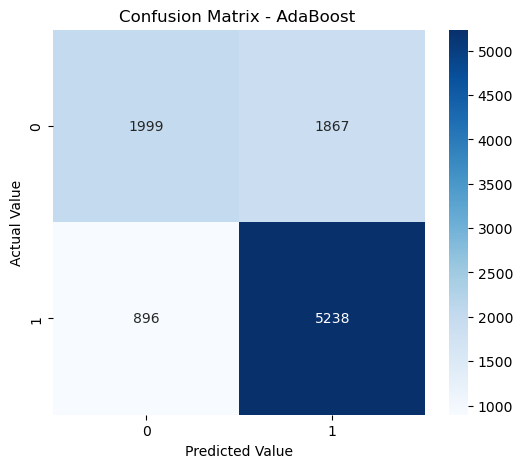

In [59]:
# Step No 21 : Confusion Matrix Visualization

# Set figure size 
plt.figure(figsize=(6,5))

# Create confusion matrix heatmap 
sns.heatmap(
    cm,
    annot=True ,
    fmt= "d",
    cmap = "Blues"
)

# Add title 
plt.title("Confusion Matrix - AdaBoost ")

# Add X-axis label 
plt.xlabel("Predicted Value")

# Add Y-axis label 
plt.ylabel("Actual Value")

# Display Graph 
plt.show()

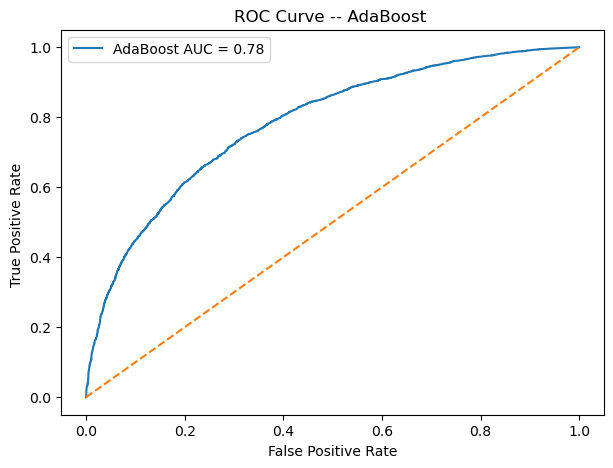

In [60]:
# Step No 22 : ROC Curve 
# Calculate False Positive Rate and True Positive Rate 
fpr , tpr , thresholds = roc_curve(
    y_test , 
    y_pred_proba
)

# Set figure size 
plt.figure(figsize=(7,5))

# Plot ROC Curve 
plt.plot(
    fpr,
    tpr,
    label = f"AdaBoost AUC = {roc_auc:.2f}"
)

# Plot random classifier line 
plt.plot(
    [0,1],
    [0,1],
    linestyle = "--"
)

# Add X-axis label 
plt.xlabel("False Positive Rate")

# Add Y-axis label 
plt.ylabel("True Positive Rate ")

# Add title 
plt.title("ROC Curve -- AdaBoost ")

# Display legend 
plt.legend()

# Display graph 
plt.show()

In [61]:
# Step No 23 : Feature Importance 
# Create feature importance DataFrame
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance_values
})

# Sort features by importance
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# Display feature importance
print(feature_importance)

                       Feature  Importance
5               Days_to_Report    0.608279
3                 Claim_Amount    0.234566
12       Claim_Frequency_Score    0.092055
11         Claim_Premium_Ratio    0.026753
28  Documentation_Complete_Yes    0.017422
15          Documentation_Risk    0.012551
8           Num_Policy_Changes    0.004985
16      Claim_History_Frequent    0.003389
20           Claim_Type_Travel    0.000000
21          Claim_Type_Vehicle    0.000000
23          Incident_Type_Loss    0.000000
22        Incident_Type_Damage    0.000000
18             Claim_Type_Life    0.000000
24       Incident_Type_Medical    0.000000
25         Incident_Type_Theft    0.000000
26         Policy_Type_Premium    0.000000
27        Policy_Type_Standard    0.000000
19         Claim_Type_Property    0.000000
0                          Age    0.000000
17         Claim_History_Minor    0.000000
1                Annual_Income    0.000000
13            Late_Report_Flag    0.000000
10         

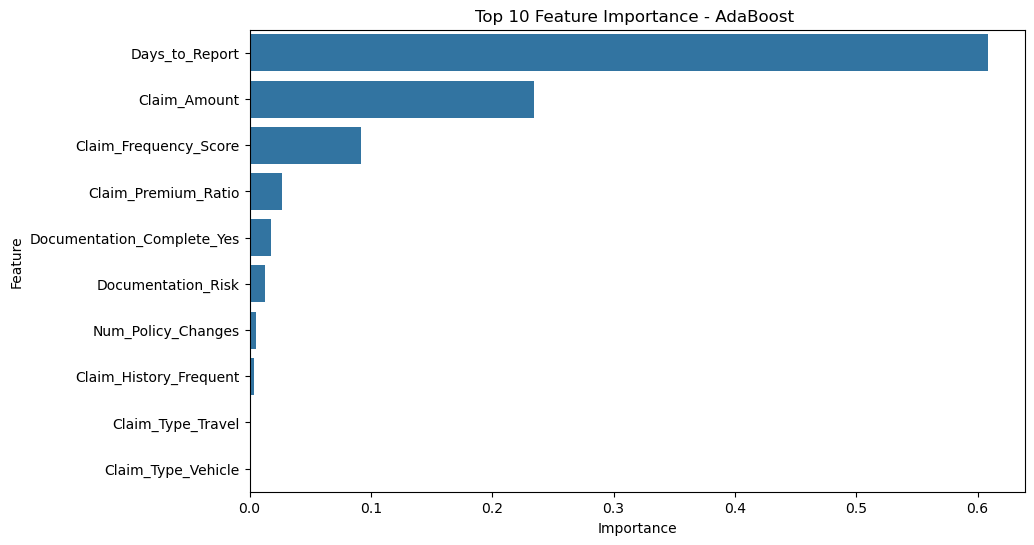

In [62]:
# Step No 24 : Feature Importance Visualization 

# Set figure size 
plt.figure(figsize=(10 , 6))

# Plot top 10 important features 
sns.barplot(
    x = "Importance",
    y = "Feature",
    data = feature_importance.head(10)
)

# Add title 
plt.title("Top 10 Feature Importance - AdaBoost ")

# Display graph 
plt.show()

In [63]:
# Step No 25 : Top 5 Features 
# Display Heading 
print("Top 5 Important Features : ")

# Display top 5  feature 
print(feature_importance.head(5))

Top 5 Important Features : 
                       Feature  Importance
5               Days_to_Report    0.608279
3                 Claim_Amount    0.234566
12       Claim_Frequency_Score    0.092055
11         Claim_Premium_Ratio    0.026753
28  Documentation_Complete_Yes    0.017422


In [64]:
# Step No 26 : User Input Prediction
# Create new insurance claim data 
new_claim = pd.DataFrame({
    # Customer age 
    "Age":[45],
    # Annual income 
    "Annual_Income": [85000],
    # Policy tenure in years
    "Policy_Tenure_Years": [5.5],
    # Claim Amount 
    "Claim_Amount": [150000],
    # Number of previous claims 
    "Number_of_Previous_Claims": [2],
    # Days taken to report claim
    "Days_to_Report": [35],
    # Policy Premium
    "Policy_Premium": [25000],
    # Vehicle age 
    "Vecicle_Age": [8],
    # Number of policy changes 
    "Num_Policy_Changes": [2],
    # Hospitalization days
    "Hospitalization_Days": [18],
    # Claim History 
    "Claim_History":["Frequent"],
    # Claim type 
    "Claim_Type": ["Vehicle"],
    # Incident type 
    "Incident_Type":["Accident"],
    # Policy type 
    "Policy_Type": ["Basic"],
    # Documentation status 
    "Documentation_Complete": ["No"]
})
# Display new claim
print(new_claim)

   Age  Annual_Income  Policy_Tenure_Years  Claim_Amount  \
0   45          85000                  5.5        150000   

   Number_of_Previous_Claims  Days_to_Report  Policy_Premium  Vecicle_Age  \
0                          2              35           25000            8   

   Num_Policy_Changes  Hospitalization_Days Claim_History Claim_Type  \
0                   2                    18      Frequent    Vehicle   

  Incident_Type Policy_Type Documentation_Complete  
0      Accident       Basic                     No  


In [65]:
# Step No 27 : Apply Same Feature Engineering 
# Create claim-to-income ratio
new_claim["Claim_Income_Ratio"] = (
    new_claim["Claim_Amount"] / 
    (new_claim["Annual_Income"] + 1)
)

# Create claim-to-premium ratio
new_claim["Claim_Premium_Ratio"] = (
    new_claim["Claim_Amount"] /
    (new_claim["Policy_Premium"] + 1)
)

# Create claim frequency score 
new_claim["Claim_Frequency_Score"] = (
    new_claim["Number_of_Previous_Claims"] + 
    new_claim["Num_Policy_Changes"]
)

# Create late reporting flag
new_claim["Late_Report_Flag"] = (
    new_claim["Days_to_Report"] > 30
).astype(int)

# Create long hospitalization flag
new_claim["Long_Hospitalization_Flag"] = (
    new_claim["Hospitalization_Days"] > 15 
).astype(int)

# Create documentation risk 
new_claim["Documentation_Risk"] = (
    new_claim["Documentation_Complete"] == "No"
).astype(int)

# Display engineered claim
print(new_claim)

   Age  Annual_Income  Policy_Tenure_Years  Claim_Amount  \
0   45          85000                  5.5        150000   

   Number_of_Previous_Claims  Days_to_Report  Policy_Premium  Vecicle_Age  \
0                          2              35           25000            8   

   Num_Policy_Changes  Hospitalization_Days  ... Claim_Type Incident_Type  \
0                   2                    18  ...    Vehicle      Accident   

  Policy_Type Documentation_Complete Claim_Income_Ratio  Claim_Premium_Ratio  \
0       Basic                     No           1.764685              5.99976   

   Claim_Frequency_Score  Late_Report_Flag  Long_Hospitalization_Flag  \
0                      4                 1                          1   

   Documentation_Risk  
0                   1  

[1 rows x 21 columns]


In [66]:
# Step No 28 : Encoded User Input
# Convert categorical columns into numerical columns 
new_claim = pd.get_dummies(
    new_claim,
    columns=categorical_columns,
    drop_first=True
)

# Match user input columns with training columns 
new_claim = new_claim.reindex(
    columns=X.columns,
    fill_value=0
)
# Display final input data 
print(new_claim)

   Age  Annual_Income  Policy_Tenure_Years  Claim_Amount  \
0   45          85000                  5.5        150000   

   Number_of_Previous_Claims  Days_to_Report  Policy_Premium  Vehicle_Age  \
0                          2              35           25000            0   

   Num_Policy_Changes  Hospitalization_Days  ...  Claim_Type_Property  \
0                   2                    18  ...                    0   

   Claim_Type_Travel  Claim_Type_Vehicle  Incident_Type_Damage  \
0                  0                   0                     0   

   Incident_Type_Loss  Incident_Type_Medical  Incident_Type_Theft  \
0                   0                      0                    0   

   Policy_Type_Premium  Policy_Type_Standard  Documentation_Complete_Yes  
0                    0                     0                           0  

[1 rows x 29 columns]


In [67]:
# Step No 29 : User Input Fraud Prediction
# Predict whether the claim is fraudulent 
new_prediction = adaboost_model.predict(
    new_claim
)

# Calculate fraud probability 
new_probability = adaboost_model.predict_proba(
    new_claim
)[0][1]

# Convert prediction into integer 
new_prediction = int(
    new_prediction[0]
)

# Check prediction result 
if new_prediction == 1 :
    # Display fraud result
    print("Claim is predicted as FRAUDULENT.")
else:
    # Display genuine result 
    print("Claim is predicted as GENUINE.")
    
# Display fraud probability 
print(
    "Fraud Probability : ",
    round(new_probability * 100 , 2),
    "%"
)

Claim is predicted as FRAUDULENT.
Fraud Probability :  71.89 %
